# Exploratory parent-group BGG offsets

## Goal

Check, outside the production pipeline, whether the BGGs of the parent Lim--Tempel/PC groups are close to the geometrical centres of their own parent groups.

This notebook intentionally keeps all derived quantities local. It reads the existing fixed catalogue products and writes only exploratory figures to `figures/exploratory/`.


## Definitions

- **Parent group:** rows in the existing `PC_Groups.csv` parent/control group catalogue, with members in `PC_Gals.csv`.
- **BGG:** the existing catalogue BGG definition, `rank_M == 1`, equivalent to the brightest member in `M_r` within each parent group.
- **Geometrical centre:** the same spherical-coordinate centroid convention used in the repository's group aggregation, `utils.spherical_utils.calc_bary`.
- **Offset:** projected distance between the parent-group BGG and that parent-group centroid.
- **R200c:** the existing parent-group `r_200_kpc` column.
- **Median pairwise projected separation:** the median projected separation over all parent-group member pairs, using the group redshift and the same angular coordinates.


In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/cg-gals-mpl")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck15
from IPython.display import Markdown, display
from scipy import stats


def find_project_root(start: Path | None = None) -> Path:
    """Find the checkout root whether the notebook is run from the repo or notebooks/."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "data" / "PC_Gals.csv").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find a CG_Gals checkout containing data/PC_Gals.csv and src/.")


PROJECT_ROOT = find_project_root()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

try:
    import config as co
except ModuleNotFoundError:
    co = None

from utils import spherical_utils as sph

CONFIG_DATA_DIR = Path(co.DATA_PATH) if co is not None else None
DATA_DIR = CONFIG_DATA_DIR if CONFIG_DATA_DIR and (CONFIG_DATA_DIR / "PC_Gals.csv").exists() else PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures" / "exploratory"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 20260703
N_PERMUTATIONS = 10_000
BOOTSTRAP_REPEATS = 10_000

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Figure directory: {FIGURE_DIR}")


Project root: /Users/matt/Astrophysics/CG_Gals
Data directory: /Users/matt/Astrophysics/CG_Gals/data
Figure directory: /Users/matt/Astrophysics/CG_Gals/figures/exploratory


## Data Loading

Load the parent group catalogue and member table directly from the existing fixed CSV products. The exploratory CG-host comparison later uses the existing `CG4_*` catalogues only to identify which parent groups host non-split CG4 systems.


In [2]:
parent_members = pd.read_csv(DATA_DIR / "PC_Gals.csv")
parent_groups = pd.read_csv(DATA_DIR / "PC_Groups.csv")
cg_members = pd.read_csv(DATA_DIR / "CG4_Gals.csv")
cg_groups = pd.read_csv(DATA_DIR / "CG4_Groups.csv")

print(f"Parent members: {len(parent_members):,} rows")
print(f"Parent groups:  {len(parent_groups):,} rows")
print(f"CG4 members:    {len(cg_members):,} rows")
print(f"CG4 groups:     {len(cg_groups):,} rows")


Parent members: 11,087 rows
Parent groups:  765 rows
CG4 members:    312 rows
CG4 groups:     78 rows


## Sanity Checks

Verify that the required columns are present and that the BGG, richness, and R200c definitions are usable.


In [3]:
GAL_REQUIRED = {"Group", "RA", "Dec", "rank_M", "M_r", "z", "objid"}
GROUP_REQUIRED = {"Group", "z_group", "RA_BGG", "Dec_BGG", "RA_Bary", "Dec_Bary", "Radius_Bary_arcmin", "Offset_Bary", "NbGal", "r_200_kpc"}

missing_gal = sorted(GAL_REQUIRED - set(parent_members.columns))
missing_group = sorted(GROUP_REQUIRED - set(parent_groups.columns))
assert not missing_gal, f"Missing parent member columns: {missing_gal}"
assert not missing_group, f"Missing parent group columns: {missing_group}"

for frame, columns in [
    (parent_members, ["Group", "RA", "Dec", "rank_M", "M_r", "z", "objid"]),
    (parent_groups, ["Group", "z_group", "RA_BGG", "Dec_BGG", "RA_Bary", "Dec_Bary", "Radius_Bary_arcmin", "Offset_Bary", "NbGal", "r_200_kpc"]),
    (cg_members, ["Group", "objid"]),
    (cg_groups, ["Group"]),
]:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

member_group_ids = set(parent_members["Group"].dropna().astype(int))
group_group_ids = set(parent_groups["Group"].dropna().astype(int))
assert member_group_ids == group_group_ids, (
    f"PC_Gals and PC_Groups group IDs differ: "
    f"{len(member_group_ids - group_group_ids)} only in members, {len(group_group_ids - member_group_ids)} only in groups"
)

richness = parent_members.groupby("Group").size().rename("richness")
bgg_counts = parent_members.assign(is_bgg=parent_members["rank_M"].eq(1)).groupby("Group")["is_bgg"].sum()
valid_r200 = parent_groups["r_200_kpc"].gt(0) & parent_groups["r_200_kpc"].notna()
rank1_is_brightest = parent_members.groupby("Group").apply(
    lambda group: group.loc[group["rank_M"].eq(1), "M_r"].min() == group["M_r"].min()
)

sanity = pd.DataFrame(
    [
        ("parent groups", parent_groups["Group"].nunique()),
        ("parent members", len(parent_members)),
        ("groups with exactly one rank_M == 1 BGG", int(bgg_counts.eq(1).sum())),
        ("groups with missing BGG", int(bgg_counts.eq(0).sum())),
        ("groups with duplicate BGG", int(bgg_counts.gt(1).sum())),
        ("groups with valid R200c", int(valid_r200.sum())),
        ("groups with richness >= 2", int(richness.ge(2).sum())),
        ("groups where rank_M == 1 is brightest M_r", int(rank1_is_brightest.sum())),
    ],
    columns=["check", "value"],
)

display(sanity)
display(richness.describe(percentiles=[0.16, 0.5, 0.84]).to_frame().T)


/var/folders/2l/5qdg19zx40sdthfzpld2xpq80000gn/T/ipykernel_49450/822931613.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank1_is_brightest = parent_members.groupby("Group").apply(


,check,value
0,parent groups,765
1,parent members,11087
2,groups with exactly one rank_M == 1 BGG,765
3,groups with missing BGG,0
4,groups with duplicate BGG,0
5,groups with valid R200c,765
6,groups with richness >= 2,765
7,groups where rank_M == 1 is brightest M_r,765


,count,mean,std,min,16%,50%,84%,max
richness,765.0,14.49281,25.06184,4.0,5.0,9.0,19.0,538.0


## Offset Calculation

For each parent group, recompute the centroid from all parent members, identify the catalogue BGG (`rank_M == 1`), and compute the BGG--centroid projected distance. The normalized offset by median pairwise projected separation should match the catalogue-level `Offset_Bary` up to numerical precision, because both are angular ratios.


In [4]:
def angular_separation_rad(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    """Vectorized angular separation in radians for degree inputs."""
    ra1 = np.deg2rad(ra1_deg)
    dec1 = np.deg2rad(dec1_deg)
    ra2 = np.deg2rad(ra2_deg)
    dec2 = np.deg2rad(dec2_deg)
    delta_ra = ra1 - ra2
    delta_dec = dec1 - dec2
    hav = np.sin(delta_dec / 2.0) ** 2 + np.cos(dec1) * np.cos(dec2) * np.sin(delta_ra / 2.0) ** 2
    return 2.0 * np.arcsin(np.sqrt(np.clip(hav, 0.0, 1.0)))


def pairwise_angular_separations_rad(ra_deg: np.ndarray, dec_deg: np.ndarray) -> np.ndarray:
    ra = np.deg2rad(np.asarray(ra_deg, dtype=float))
    dec = np.deg2rad(np.asarray(dec_deg, dtype=float))
    delta_ra = ra[:, None] - ra[None, :]
    delta_dec = dec[:, None] - dec[None, :]
    hav = np.sin(delta_dec / 2.0) ** 2 + np.cos(dec[:, None]) * np.cos(dec[None, :]) * np.sin(delta_ra / 2.0) ** 2
    matrix = 2.0 * np.arcsin(np.sqrt(np.clip(hav, 0.0, 1.0)))
    upper = np.triu_indices(len(ra), k=1)
    return matrix[upper]


def projected_kpc(theta_rad: np.ndarray | float, z_group: float) -> np.ndarray | float:
    return np.asarray(theta_rad) * Planck15.angular_diameter_distance(float(z_group)).to_value("kpc")


def calculate_parent_offsets(members: pd.DataFrame, groups: pd.DataFrame):
    group_lookup = groups.set_index("Group")
    rows: list[dict] = []
    exclusions: list[dict] = []
    member_offset_lookup: dict[int, dict[str, np.ndarray]] = {}

    for group_id, raw_group in members.groupby("Group", sort=True):
        if group_id not in group_lookup.index:
            exclusions.append({"Group": group_id, "reason": "missing_group_row"})
            continue

        group_row = group_lookup.loc[group_id]
        required = raw_group[["RA", "Dec", "rank_M", "M_r", "z"]].apply(pd.to_numeric, errors="coerce")
        clean = raw_group.loc[required.notna().all(axis=1)].copy()
        for column in ["RA", "Dec", "rank_M", "M_r", "z"]:
            clean[column] = pd.to_numeric(clean[column], errors="coerce")

        if len(clean) < 2:
            exclusions.append({"Group": group_id, "reason": "fewer_than_two_valid_members"})
            continue

        bgg = clean.loc[clean["rank_M"].eq(1)]
        if len(bgg) == 0:
            exclusions.append({"Group": group_id, "reason": "missing_rank1_bgg"})
            continue
        if len(bgg) > 1:
            exclusions.append({"Group": group_id, "reason": "duplicate_rank1_bgg"})
            continue

        z_group = pd.to_numeric(group_row.get("z_group"), errors="coerce")
        if not np.isfinite(z_group):
            z_group = float(clean["z"].median())
        r200_kpc = pd.to_numeric(group_row.get("r_200_kpc"), errors="coerce")
        if not np.isfinite(r200_kpc) or r200_kpc <= 0:
            exclusions.append({"Group": group_id, "reason": "invalid_r200c"})
            continue

        pairwise_rad = pairwise_angular_separations_rad(clean["RA"].to_numpy(), clean["Dec"].to_numpy())
        pairwise_rad = pairwise_rad[np.isfinite(pairwise_rad) & (pairwise_rad > 0)]
        if len(pairwise_rad) == 0:
            exclusions.append({"Group": group_id, "reason": "invalid_pairwise_separations"})
            continue

        ra_centroid, dec_centroid = sph.calc_bary(clean)
        bgg_row = bgg.iloc[0]
        bgg_theta_rad = float(angular_separation_rad(bgg_row["RA"], bgg_row["Dec"], ra_centroid, dec_centroid))
        bgg_d_kpc = float(projected_kpc(bgg_theta_rad, z_group))
        median_pairwise_rad = float(np.median(pairwise_rad))
        median_pairwise_kpc = float(projected_kpc(median_pairwise_rad, z_group))

        member_theta_rad = angular_separation_rad(clean["RA"].to_numpy(), clean["Dec"].to_numpy(), ra_centroid, dec_centroid)
        member_d_kpc = projected_kpc(member_theta_rad, z_group).astype(float)
        member_offset_lookup[int(group_id)] = {
            "r200": member_d_kpc / r200_kpc,
            "pairwise": member_d_kpc / median_pairwise_kpc,
            "kpc": member_d_kpc,
        }

        rows.append(
            {
                "Group": int(group_id),
                "richness": int(len(clean)),
                "z_group": float(z_group),
                "r200c_parent_kpc": float(r200_kpc),
                "ra_centroid_deg": float(ra_centroid),
                "dec_centroid_deg": float(dec_centroid),
                "ra_bgg_deg": float(bgg_row["RA"]),
                "dec_bgg_deg": float(bgg_row["Dec"]),
                "bgg_M_r": float(bgg_row["M_r"]),
                "d_bgg_parent_centroid_arcmin": float(np.rad2deg(bgg_theta_rad) * 60.0),
                "d_bgg_parent_centroid_kpc": bgg_d_kpc,
                "d_bgg_parent_centroid_over_R200c_parent": bgg_d_kpc / r200_kpc,
                "median_pairwise_projected_separation_parent_kpc": median_pairwise_kpc,
                "median_pairwise_angular_arcmin": float(np.rad2deg(median_pairwise_rad) * 60.0),
                "d_bgg_parent_centroid_over_median_pairwise_projected_separation_parent": bgg_d_kpc / median_pairwise_kpc,
                "existing_Offset_Bary": float(group_row["Offset_Bary"]),
                "existing_Radius_Bary_arcmin": float(group_row["Radius_Bary_arcmin"]),
            }
        )

    return pd.DataFrame(rows), pd.DataFrame(exclusions), member_offset_lookup


offsets, exclusions, member_offsets = calculate_parent_offsets(parent_members, parent_groups)

offsets["delta_vs_existing_Offset_Bary"] = (
    offsets["d_bgg_parent_centroid_over_median_pairwise_projected_separation_parent"]
    - offsets["existing_Offset_Bary"]
)
offsets["delta_vs_existing_Radius_Bary_arcmin"] = offsets["median_pairwise_angular_arcmin"] - offsets["existing_Radius_Bary_arcmin"]

print(f"Computed offsets for {len(offsets):,} parent groups")
print(f"Excluded groups: {len(exclusions):,}")
if len(exclusions):
    display(exclusions["reason"].value_counts().rename_axis("reason").reset_index(name="n"))

cross_checks = pd.DataFrame(
    {
        "quantity": ["Offset_Bary", "Radius_Bary_arcmin"],
        "max_abs_delta": [
            offsets["delta_vs_existing_Offset_Bary"].abs().max(),
            offsets["delta_vs_existing_Radius_Bary_arcmin"].abs().max(),
        ],
        "median_abs_delta": [
            offsets["delta_vs_existing_Offset_Bary"].abs().median(),
            offsets["delta_vs_existing_Radius_Bary_arcmin"].abs().median(),
        ],
    }
)
display(cross_checks)
display(offsets.head())


Computed offsets for 765 parent groups
Excluded groups: 0


,quantity,max_abs_delta,median_abs_delta
0,Offset_Bary,5.090667e-10,1.196254e-11
1,Radius_Bary_arcmin,6.315588e-10,4.386003e-11


,Group,richness,z_group,r200c_parent_kpc,ra_centroid_deg,dec_centroid_deg,ra_bgg_deg,dec_bgg_deg,bgg_M_r,d_bgg_parent_centroid_arcmin,d_bgg_parent_centroid_kpc,d_bgg_parent_centroid_over_R200c_parent,median_pairwise_projected_separation_parent_kpc,median_pairwise_angular_arcmin,d_bgg_parent_centroid_over_median_pairwise_projected_separation_parent,existing_Offset_Bary,existing_Radius_Bary_arcmin,delta_vs_existing_Offset_Bary,delta_vs_existing_Radius_Bary_arcmin
0,1,538,0.023882,1431.177342,194.783739,27.871535,195.033862,27.976941,-23.504925,14.691004,438.687207,0.306522,1475.113584,49.399433,0.297392,0.297392,49.399433,1.431355e-12,1.249134e-11
1,3,177,0.037409,1185.234200,240.635714,16.165252,240.582744,16.345990,-23.177717,11.265320,518.391604,0.437375,1139.197353,24.756233,0.455050,0.455050,24.756233,-6.252832e-12,1.927347e-11
2,5,156,0.021936,1039.106238,176.055941,19.883818,176.008980,19.949825,-23.000761,4.764796,130.995641,0.126066,986.245824,35.873405,0.132823,0.132823,35.873405,-6.190604e-13,2.714273e-12
3,6,149,0.041737,1543.557343,234.929272,21.726994,234.912689,21.782716,-23.516548,3.468680,177.162814,0.114776,1484.577760,29.066628,0.119335,0.119335,29.066628,-4.199557e-13,-1.448797e-11
4,13,123,0.027659,1019.311923,220.151449,3.495976,220.178481,3.465423,-22.911837,2.445685,84.195298,0.082600,1068.642472,31.041672,0.078787,0.078787,31.041672,-2.236318e-11,2.273737e-12


## Summary Statistics

Report central tendency, scatter, percentile intervals, bootstrap confidence intervals for the median, and fractions below practical centrality thresholds.


In [5]:
def bootstrap_median_ci(values, rng, repeats=BOOTSTRAP_REPEATS):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return {"median_bootstrap_ci68_low": np.nan, "median_bootstrap_ci68_high": np.nan, "median_bootstrap_ci95_low": np.nan, "median_bootstrap_ci95_high": np.nan}
    samples = rng.choice(values, size=(repeats, len(values)), replace=True)
    medians = np.median(samples, axis=1)
    return {
        "median_bootstrap_ci68_low": float(np.percentile(medians, 16)),
        "median_bootstrap_ci68_high": float(np.percentile(medians, 84)),
        "median_bootstrap_ci95_low": float(np.percentile(medians, 2.5)),
        "median_bootstrap_ci95_high": float(np.percentile(medians, 97.5)),
    }


def summary_stats(values, label):
    rng = np.random.default_rng(RNG_SEED)
    series = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    base = {
        "quantity": label,
        "n": int(series.size),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)),
        "median": float(series.median()),
        "p16": float(series.quantile(0.16)),
        "p84": float(series.quantile(0.84)),
    }
    base.update(bootstrap_median_ci(series.to_numpy(), rng=rng))
    return base


def fractions_below(values, thresholds, label):
    series = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    return pd.DataFrame(
        {
            "quantity": label,
            "threshold": thresholds,
            "n": int(series.size),
            "fraction_below": [float((series < threshold).mean()) for threshold in thresholds],
            "percent_below": [100.0 * float((series < threshold).mean()) for threshold in thresholds],
        }
    )

METRIC_R200 = "d_bgg_parent_centroid_over_R200c_parent"
METRIC_PAIRWISE = "d_bgg_parent_centroid_over_median_pairwise_projected_separation_parent"
METRIC_KPC = "d_bgg_parent_centroid_kpc"

summary = pd.DataFrame(
    [
        summary_stats(offsets[METRIC_R200], "offset / R200c"),
        summary_stats(offsets[METRIC_PAIRWISE], "offset / median pairwise separation"),
        summary_stats(offsets[METRIC_KPC], "offset [kpc]"),
    ]
)

table_fractions = pd.concat(
    [
        fractions_below(offsets[METRIC_R200], [0.05, 0.10, 0.20, 0.30], "offset / R200c"),
        fractions_below(offsets[METRIC_PAIRWISE], [0.10, 0.20, 0.30, 0.50], "offset / median pairwise separation"),
    ],
    ignore_index=True,
)

display(summary)
display(table_fractions)


,quantity,n,mean,std,median,p16,p84,median_bootstrap_ci68_low,median_bootstrap_ci68_high,median_bootstrap_ci95_low,median_bootstrap_ci95_high
0,offset / R200c,765,0.393664,0.257091,0.343374,0.155913,0.635210,0.335339,0.350862,0.324498,0.358419
1,offset / median pairwise separation,765,0.431027,0.263122,0.397744,0.187999,0.668551,0.378977,0.406263,0.362716,0.417784
2,offset [kpc],765,219.572775,156.680049,178.752423,81.606588,366.089136,173.625464,185.031319,167.206236,191.440880


,quantity,threshold,n,fraction_below,percent_below
0,offset / R200c,0.05,765,0.016993,1.699346
1,offset / R200c,0.10,765,0.081046,8.104575
2,offset / R200c,0.20,765,0.237908,23.790850
3,offset / R200c,0.30,765,0.418301,41.830065
4,offset / median pairwise separation,0.10,765,0.061438,6.143791
5,offset / median pairwise separation,0.20,765,0.173856,17.385621
6,offset / median pairwise separation,0.30,765,0.371242,37.124183
7,offset / median pairwise separation,0.50,765,0.673203,67.320261


## Null Model / Significance

Build a within-parent-group null model by replacing the real BGG with a uniformly random group member. The centroid is held fixed for each group. The primary one-sided p-value is the fraction of null realizations whose median offset is as small as, or smaller than, the observed BGG median offset.


In [6]:
def build_group_balanced_null(offsets_df, member_offset_lookup, member_metric_key, observed_column, rng, n_permutations=N_PERMUTATIONS):
    group_ids = offsets_df["Group"].astype(int).to_numpy()
    observed = offsets_df.set_index("Group").loc[group_ids, observed_column].to_numpy(dtype=float)
    draws = np.empty((n_permutations, len(group_ids)), dtype=float)
    for column, group_id in enumerate(group_ids):
        values = np.asarray(member_offset_lookup[int(group_id)][member_metric_key], dtype=float)
        draws[:, column] = values[rng.integers(0, len(values), size=n_permutations)]
    null_medians = np.median(draws, axis=1)
    paired_delta_medians = np.median(draws - observed[None, :], axis=1)
    return group_ids, observed, draws, null_medians, paired_delta_medians


def one_sided_central_pvalue(observed_median, null_medians):
    return float((np.sum(null_medians <= observed_median) + 1.0) / (len(null_medians) + 1.0))


def paired_central_pvalue(paired_delta_medians):
    return float((np.sum(paired_delta_medians <= 0.0) + 1.0) / (len(paired_delta_medians) + 1.0))


def anderson_ksamp_safe(samples):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = stats.anderson_ksamp(samples)
    pvalue = getattr(result, "pvalue", None)
    if pvalue is None:
        pvalue = getattr(result, "significance_level", np.nan)
        if np.isfinite(pvalue):
            pvalue = pvalue / 100.0
    return float(result.statistic), float(pvalue)

rng_null = np.random.default_rng(RNG_SEED)
group_ids, observed_r200, null_draws_r200, null_medians_r200, paired_delta_r200 = build_group_balanced_null(
    offsets, member_offsets, "r200", METRIC_R200, rng_null
)
_, observed_pairwise, null_draws_pairwise, null_medians_pairwise, paired_delta_pairwise = build_group_balanced_null(
    offsets, member_offsets, "pairwise", METRIC_PAIRWISE, rng_null
)

# One seeded, group-balanced random-member draw is used for distribution tests so tests do not rely on millions of pseudo-replicated rows.
balanced_random_r200 = null_draws_r200[0]
balanced_random_pairwise = null_draws_pairwise[0]
ks_r200 = stats.ks_2samp(observed_r200, balanced_random_r200, alternative="two-sided", method="auto")
ks_pairwise = stats.ks_2samp(observed_pairwise, balanced_random_pairwise, alternative="two-sided", method="auto")
ad_r200_stat, ad_r200_p = anderson_ksamp_safe([observed_r200, balanced_random_r200])
ad_pairwise_stat, ad_pairwise_p = anderson_ksamp_safe([observed_pairwise, balanced_random_pairwise])

null_results = pd.DataFrame(
    [
        {
            "quantity": "offset / R200c",
            "observed_median": float(np.median(observed_r200)),
            "null_median_distribution_median": float(np.median(null_medians_r200)),
            "null_median_distribution_p16": float(np.percentile(null_medians_r200, 16)),
            "null_median_distribution_p84": float(np.percentile(null_medians_r200, 84)),
            "one_sided_p_real_bggs_more_central": one_sided_central_pvalue(np.median(observed_r200), null_medians_r200),
            "paired_permutation_p": paired_central_pvalue(paired_delta_r200),
            "ks_statistic_seeded_balanced_draw": float(ks_r200.statistic),
            "ks_pvalue_seeded_balanced_draw": float(ks_r200.pvalue),
            "anderson_statistic_seeded_balanced_draw": ad_r200_stat,
            "anderson_pvalue_seeded_balanced_draw": ad_r200_p,
        },
        {
            "quantity": "offset / median pairwise separation",
            "observed_median": float(np.median(observed_pairwise)),
            "null_median_distribution_median": float(np.median(null_medians_pairwise)),
            "null_median_distribution_p16": float(np.percentile(null_medians_pairwise, 16)),
            "null_median_distribution_p84": float(np.percentile(null_medians_pairwise, 84)),
            "one_sided_p_real_bggs_more_central": one_sided_central_pvalue(np.median(observed_pairwise), null_medians_pairwise),
            "paired_permutation_p": paired_central_pvalue(paired_delta_pairwise),
            "ks_statistic_seeded_balanced_draw": float(ks_pairwise.statistic),
            "ks_pvalue_seeded_balanced_draw": float(ks_pairwise.pvalue),
            "anderson_statistic_seeded_balanced_draw": ad_pairwise_stat,
            "anderson_pvalue_seeded_balanced_draw": ad_pairwise_p,
        },
    ]
)

display(null_results)


,quantity,observed_median,null_median_distribution_median,null_median_distribution_p16,null_median_distribution_p84,one_sided_p_real_bggs_more_central,paired_permutation_p,ks_statistic_seeded_balanced_draw,ks_pvalue_seeded_balanced_draw,anderson_statistic_seeded_balanced_draw,anderson_pvalue_seeded_balanced_draw
0,offset / R200c,0.343374,0.576210,0.556301,0.590024,0.0001,0.0001,0.304575,1.015986e-31,123.200591,0.001
1,offset / median pairwise separation,0.397744,0.636789,0.619157,0.653776,0.0001,0.0001,0.332026,9.903860e-38,122.305318,0.001


## Optional Host Comparison

As a lightweight reference check, identify parent groups that host at least one non-split CG4 using the existing `objid` overlap between `CG4_Gals.csv` and `PC_Gals.csv`. This is not a newly designed control sample; it only splits the already-loaded parent catalogue into CG-hosting and non-CG-hosting parent groups.


In [7]:
def identify_non_split_cg4_parent_groups(cg_members, cg_groups, parent_members):
    if "Class" in cg_groups.columns:
        non_split_cg_ids = set(cg_groups.loc[cg_groups["Class"].ne("Split"), "Group"].dropna().astype(int))
    else:
        non_split_cg_ids = set(cg_groups["Group"].dropna().astype(int))
    cg_subset = cg_members.loc[cg_members["Group"].astype(int).isin(non_split_cg_ids), ["objid", "Group"]].copy()
    mapping = cg_subset.merge(
        parent_members[["objid", "Group"]].copy(),
        on="objid",
        how="inner",
        suffixes=("_cg4", "_parent"),
        validate="m:m",
    )
    parent_per_cg = mapping.groupby("Group_cg4")["Group_parent"].nunique()
    return set(mapping["Group_parent"].dropna().astype(int)), mapping, parent_per_cg


def permutation_median_difference_pvalue(a, b, rng, repeats=N_PERMUTATIONS):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    observed = float(np.median(a) - np.median(b))
    combined = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(repeats):
        permuted = rng.permutation(combined)
        diff = np.median(permuted[:n_a]) - np.median(permuted[n_a:])
        if abs(diff) >= abs(observed):
            count += 1
    return observed, float((count + 1.0) / (repeats + 1.0))

host_parent_groups, cg_parent_mapping, parent_groups_per_cg = identify_non_split_cg4_parent_groups(cg_members, cg_groups, parent_members)
offsets["hosts_non_split_cg4"] = offsets["Group"].astype(int).isin(host_parent_groups)

print(f"Non-split CG4 groups mapped to parent groups: {parent_groups_per_cg.size}")
print(f"Parent groups hosting non-split CG4s: {len(host_parent_groups)}")
print("CG4 groups per parent-group mapping counts:")
display(parent_groups_per_cg.value_counts().rename_axis("parent_groups_per_cg4").reset_index(name="n_cg4_groups"))

comparison_rows = []
rng_compare = np.random.default_rng(RNG_SEED)
for metric, label in [(METRIC_R200, "offset / R200c"), (METRIC_PAIRWISE, "offset / median pairwise separation")]:
    host = offsets.loc[offsets["hosts_non_split_cg4"], metric].dropna().to_numpy()
    non_host = offsets.loc[~offsets["hosts_non_split_cg4"], metric].dropna().to_numpy()
    if len(host) >= 2 and len(non_host) >= 2:
        mw = stats.mannwhitneyu(host, non_host, alternative="two-sided")
        ks = stats.ks_2samp(host, non_host, alternative="two-sided", method="auto")
        diff, perm_p = permutation_median_difference_pvalue(host, non_host, rng_compare)
        comparison_rows.append(
            {
                "quantity": label,
                "n_cg_host_parent_groups": len(host),
                "n_non_host_parent_groups": len(non_host),
                "median_cg_host": float(np.median(host)),
                "median_non_host": float(np.median(non_host)),
                "median_difference_host_minus_nonhost": diff,
                "permutation_p_two_sided": perm_p,
                "mann_whitney_u_p_two_sided": float(mw.pvalue),
                "ks_p_two_sided": float(ks.pvalue),
            }
        )

host_comparison = pd.DataFrame(comparison_rows)
display(host_comparison)


Non-split CG4 groups mapped to parent groups: 62
Parent groups hosting non-split CG4s: 60
CG4 groups per parent-group mapping counts:


,parent_groups_per_cg4,n_cg4_groups
0,1,62


,quantity,n_cg_host_parent_groups,n_non_host_parent_groups,median_cg_host,median_non_host,median_difference_host_minus_nonhost,permutation_p_two_sided,mann_whitney_u_p_two_sided,ks_p_two_sided
0,offset / R200c,60,705,0.275649,0.348687,-0.073038,0.047895,0.042247,0.048411
1,offset / median pairwise separation,60,705,0.370033,0.398444,-0.028412,0.574543,0.503810,0.277950


## Figures

The figure overlays the observed parent-BGG offset ECDF with the group-balanced random-member null distribution. The null ECDF uses a plotting subset of repeated group-balanced draws; statistical p-values use all `N_PERMUTATIONS` median-null realizations above.


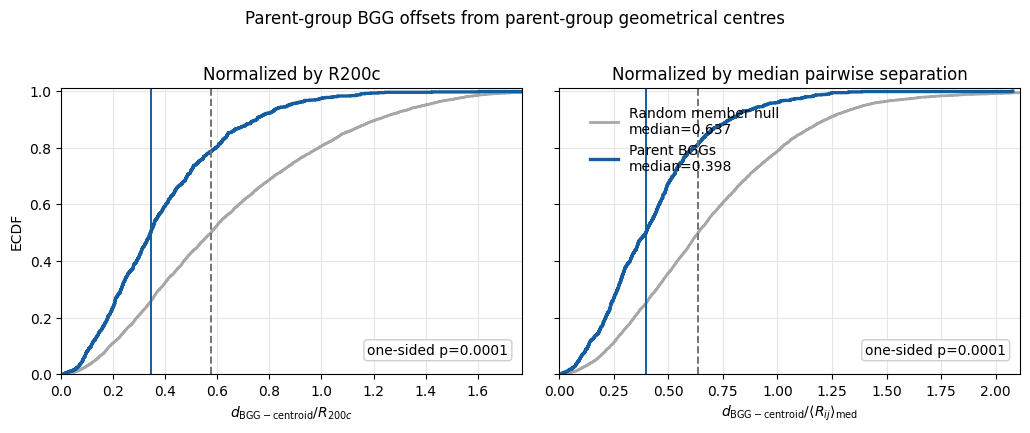

Saved /Users/matt/Astrophysics/CG_Gals/figures/exploratory/parent_bgg_offsets.png
Saved /Users/matt/Astrophysics/CG_Gals/figures/exploratory/parent_bgg_offsets.pdf


In [8]:
def ecdf(values):
    values = np.asarray(pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna(), dtype=float)
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_offset_ecdfs():
    null_display_repeats = min(1000, N_PERMUTATIONS)
    panels = [
        {
            "ax_title": "Normalized by R200c",
            "xlabel": r"$d_{\rm BGG-centroid}/R_{200c}$",
            "observed": observed_r200,
            "null_pool": null_draws_r200[:null_display_repeats].ravel(),
            "observed_median": float(np.median(observed_r200)),
            "null_median": float(np.median(null_medians_r200)),
            "pvalue": one_sided_central_pvalue(np.median(observed_r200), null_medians_r200),
        },
        {
            "ax_title": "Normalized by median pairwise separation",
            "xlabel": r"$d_{\rm BGG-centroid}/\langle R_{ij}\rangle_{\rm med}$",
            "observed": observed_pairwise,
            "null_pool": null_draws_pairwise[:null_display_repeats].ravel(),
            "observed_median": float(np.median(observed_pairwise)),
            "null_median": float(np.median(null_medians_pairwise)),
            "pvalue": one_sided_central_pvalue(np.median(observed_pairwise), null_medians_pairwise),
        },
    ]

    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), sharey=True)
    for ax, panel in zip(axes, panels):
        x_obs, y_obs = ecdf(panel["observed"])
        x_null, y_null = ecdf(panel["null_pool"])
        ax.step(x_null, y_null, where="post", color="0.62", linewidth=2.0, alpha=0.9, label=f"Random member null\nmedian={panel['null_median']:.3f}")
        ax.step(x_obs, y_obs, where="post", color="#145DA0", linewidth=2.4, label=f"Parent BGGs\nmedian={panel['observed_median']:.3f}")
        ax.axvline(panel["null_median"], color="0.45", linestyle="--", linewidth=1.4)
        ax.axvline(panel["observed_median"], color="#145DA0", linestyle="-", linewidth=1.4)
        xmax = np.nanpercentile(np.concatenate([panel["observed"], panel["null_pool"]]), 99.2)
        ax.set_xlim(0, xmax * 1.05)
        ax.set_ylim(0, 1.01)
        ax.grid(True, color="0.9", linewidth=0.8)
        ax.set_title(panel["ax_title"])
        ax.set_xlabel(panel["xlabel"])
        ax.text(
            0.97,
            0.06,
            f"one-sided p={panel['pvalue']:.3g}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.8", "alpha": 0.95},
        )
    axes[0].set_ylabel("ECDF")
    axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(0.04, 0.98))
    fig.suptitle("Parent-group BGG offsets from parent-group geometrical centres", y=1.02)
    fig.tight_layout()
    return fig

fig = plot_offset_ecdfs()
png_path = FIGURE_DIR / "parent_bgg_offsets.png"
pdf_path = FIGURE_DIR / "parent_bgg_offsets.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved {png_path}")
print(f"Saved {pdf_path}")


## Caveats

- The test is projected: offsets use sky coordinates and group redshift distances, not full 3D positions.
- The random-member null conditions on the observed parent-group membership and centroid; it asks whether the catalogue BGG is more central than a randomly selected existing member.
- If the parent catalogue, BGG definition, or selected-core construction is partly BGG-centred, BGG centrality may partly arise by construction.
- The optional CG-host comparison is descriptive and reuses the existing parent catalogue split; it is not a newly designed control sample.


## Interpretation

The final cell turns the numeric results into a concise referee-style statement. The caveat is important: if the parent catalogue or control-core construction is partly BGG-centred, measured centrality is not an independent dynamical discovery.


In [9]:
median_r200 = float(summary.loc[summary["quantity"].eq("offset / R200c"), "median"].iloc[0])
frac_010 = float(table_fractions.loc[(table_fractions["quantity"].eq("offset / R200c")) & (table_fractions["threshold"].eq(0.10)), "percent_below"].iloc[0])
frac_020 = float(table_fractions.loc[(table_fractions["quantity"].eq("offset / R200c")) & (table_fractions["threshold"].eq(0.20)), "percent_below"].iloc[0])
p_r200 = float(null_results.loc[null_results["quantity"].eq("offset / R200c"), "one_sided_p_real_bggs_more_central"].iloc[0])
null_median_r200 = float(null_results.loc[null_results["quantity"].eq("offset / R200c"), "null_median_distribution_median"].iloc[0])

centrality_phrase = "more" if (median_r200 < null_median_r200 and p_r200 < 0.05) else "not more"
closeness_phrase = "are close" if (median_r200 < 0.20 and frac_020 >= 50.0) else "are not uniformly close"

conclusion = (
    f"The median parent-BGG offset is {median_r200:.3f} R200c, with {frac_010:.1f}% of parent BGGs within "
    f"0.1 R200c and {frac_020:.1f}% within 0.2 R200c. Relative to random group members, parent BGGs are "
    f"{centrality_phrase} centrally located, with p = {p_r200:.3g}. This suggests that parent-group BGGs "
    f"{closeness_phrase} to their geometrical centres, but this should be interpreted cautiously because the parent "
    f"catalogue or selected-core construction may be BGG-centred by construction."
)

display(Markdown(conclusion))
print(conclusion)


The median parent-BGG offset is 0.343 R200c, with 8.1% of parent BGGs within 0.1 R200c and 23.8% within 0.2 R200c. Relative to random group members, parent BGGs are more centrally located, with p = 0.0001. This suggests that parent-group BGGs are not uniformly close to their geometrical centres, but this should be interpreted cautiously because the parent catalogue or selected-core construction may be BGG-centred by construction.

The median parent-BGG offset is 0.343 R200c, with 8.1% of parent BGGs within 0.1 R200c and 23.8% within 0.2 R200c. Relative to random group members, parent BGGs are more centrally located, with p = 0.0001. This suggests that parent-group BGGs are not uniformly close to their geometrical centres, but this should be interpreted cautiously because the parent catalogue or selected-core construction may be BGG-centred by construction.
